# 01 — Data Quality & Schema Assessment

**Objective:** Thorough inspection of the three source datasets for a Bitcoin mining site —
telemetry, miner registry, and BTC economics — before any modelling work begins.

We check completeness, validity, value ranges, and propose schema improvements.

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

DATA = Path("/home/ricardo/dev/hdrn/leads/tether/prep/dry-run")
print("Data directory:", DATA)

Data directory: /home/ricardo/dev/hdrn/leads/tether/prep/dry-run


## 1. Data Loading & First Look

In [2]:
# Load CSVs — keep_default_na=False so that empty strings stay as "" instead of NaN.
# This lets us distinguish genuine blanks from true missing values.
telem = pd.read_csv(DATA / "site_telemetry.csv", keep_default_na=False)
registry = pd.read_csv(DATA / "miner_registry.csv")
econ = pd.read_csv(DATA / "btc_economics.csv")

print("=== Shapes ===")
for name, df in [("site_telemetry", telem), ("miner_registry", registry), ("btc_economics", econ)]:
    print(f"  {name:20s}  {str(df.shape):>14s}   ({df.memory_usage(deep=True).sum()/1e6:.1f} MB)")

print(f"\nTelemetry: {telem.shape[0]:,} rows  x  {telem.shape[1]} columns")
print(f"Registry:  {registry.shape[0]:,} rows  x  {registry.shape[1]} columns")
print(f"Economics: {econ.shape[0]:,} rows  x  {econ.shape[1]} columns")

=== Shapes ===
  site_telemetry          (725760, 21)   (187.9 MB)
  miner_registry              (180, 8)   (0.0 MB)
  btc_economics               (336, 5)   (0.0 MB)

Telemetry: 725,760 rows  x  21 columns
Registry:  180 rows  x  8 columns
Economics: 336 rows  x  5 columns


In [3]:
# Dtypes overview
print("=== site_telemetry dtypes ===")
print(telem.dtypes.to_string())
print("\n=== miner_registry dtypes ===")
print(registry.dtypes.to_string())
print("\n=== btc_economics dtypes ===")
print(econ.dtypes.to_string())

=== site_telemetry dtypes ===
timestamp                       str
miner_id                        str
container                       str
position                        str
model                           str
status                          str
power_mode                      str
hashrate_th_5m                  str
hashrate_th_avg                 str
power_w                         str
efficiency_wth                  str
chip_temp_c                     str
board_temp_c                    str
inlet_temp_c                float64
fan_speed_rpm                   str
accepted_shares                 str
rejected_shares                 str
stale_shares                    str
frequency_mhz                   str
uptime_hours                float64
electricity_rate_usd_kwh    float64

=== miner_registry dtypes ===
miner_id                      str
container                     str
position                      str
model                         str
cooling                       str
nominal_hashr

In [4]:
# First and last rows
print("=== Telemetry — first 3 rows ===")
display(telem.head(3))
print("\n=== Telemetry — last 3 rows ===")
display(telem.tail(3))

=== Telemetry — first 3 rows ===


,timestamp,miner_id,container,position,model,status,power_mode,hashrate_th_5m,hashrate_th_avg,power_w,efficiency_wth,chip_temp_c,board_temp_c,inlet_temp_c,fan_speed_rpm,accepted_shares,rejected_shares,stale_shares,frequency_mhz,uptime_hours,electricity_rate_usd_kwh
0,2026-04-09T00:00:00,MNR-0001,A,R1_01,S21,mining,normal,197.0,198.69,3504.2,17.79,55.9,48.2,18.3,3623,3,0,0,493.6,1.8,0.0276
1,2026-04-09T00:00:00,MNR-0002,A,R1_02,S21,mining,normal,204.37,200.08,3516.7,17.21,55.5,48.2,18.6,3571,4,0,0,498.8,0.0,0.0276
2,2026-04-09T00:00:00,MNR-0003,A,R1_03,S21,mining,normal,199.78,198.78,3478.5,17.41,51.4,43.7,18.4,3353,3,0,0,514.3,0.0,0.0276



=== Telemetry — last 3 rows ===


,timestamp,miner_id,container,position,model,status,power_mode,hashrate_th_5m,hashrate_th_avg,power_w,efficiency_wth,chip_temp_c,board_temp_c,inlet_temp_c,fan_speed_rpm,accepted_shares,rejected_shares,stale_shares,frequency_mhz,uptime_hours,electricity_rate_usd_kwh
725757,2026-04-22T23:55:00,MNR-0178,C,R6_08,M63,mining,normal,405.32,398.97,7307.3,18.03,57.4,47.8,22.7,3622,8,0,0,505.3,336.0,0.0316
725758,2026-04-22T23:55:00,MNR-0179,C,R6_09,M63,mining,normal,405.98,402.49,7415.7,18.27,56.0,48.9,21.2,3477,8,0,0,513.1,335.2,0.0316
725759,2026-04-22T23:55:00,MNR-0180,C,R6_10,M63,mining,normal,397.79,397.97,7414.7,18.64,59.1,50.2,22.8,3797,7,0,0,493.6,336.6,0.0316


In [5]:
# Time range
ts_min = telem["timestamp"].min()
ts_max = telem["timestamp"].max()
print(f"Telemetry time range: {ts_min}  -->  {ts_max}")

econ_min = econ["timestamp"].min()
econ_max = econ["timestamp"].max()
print(f"Economics time range: {econ_min}  -->  {econ_max}")

# Parse timestamps for later use
telem["timestamp"] = pd.to_datetime(telem["timestamp"])
econ["timestamp"] = pd.to_datetime(econ["timestamp"])
days = (telem["timestamp"].max() - telem["timestamp"].min()).total_seconds() / 86400
print(f"\nTelemetry spans {days:.1f} days")

Telemetry time range: 2026-04-09T00:00:00  -->  2026-04-22T23:55:00
Economics time range: 2026-04-09T00:00:00  -->  2026-04-22T23:00:00

Telemetry spans 14.0 days


## 2. Missing Data Analysis

The CSV uses empty strings (`""`) for missing values rather than explicit `NaN`.
We loaded with `keep_default_na=False` to preserve this, so we detect blanks as `== ""`.

In [6]:
# Count blanks (empty strings) per column in telemetry
blank_counts = (telem.astype(str) == "").sum()
blank_pct = (blank_counts / len(telem) * 100).round(2)

missing_df = pd.DataFrame({"blank_count": blank_counts, "blank_pct": blank_pct})
missing_df = missing_df[missing_df["blank_count"] > 0].sort_values("blank_count", ascending=False)

if len(missing_df) == 0:
    print("No blank values found in telemetry.")
    # Also check for NaN just in case
    nan_counts = telem.isna().sum()
    nan_any = nan_counts[nan_counts > 0]
    if len(nan_any) > 0:
        print("\nHowever, NaN values detected:")
        print(nan_any)
    else:
        print("No NaN values either — dataset appears fully populated.")
else:
    print("Columns with blank values:")
    display(missing_df)

# Also check registry and economics
print("\n=== Registry missing ===")
print(registry.isna().sum().to_string())
print("\n=== Economics missing ===")
print(econ.isna().sum().to_string())

Columns with blank values:


,blank_count,blank_pct
board_temp_c,9297,1.28
chip_temp_c,9297,1.28
efficiency_wth,9297,1.28
power_w,7155,0.99
hashrate_th_avg,7155,0.99
hashrate_th_5m,7155,0.99
fan_speed_rpm,7155,0.99
accepted_shares,7155,0.99
rejected_shares,7155,0.99
stale_shares,7155,0.99



=== Registry missing ===
miner_id                  0
container                 0
position                  0
model                     0
cooling                   0
nominal_hashrate_th       0
nominal_power_w           0
nominal_efficiency_wth    0

=== Economics missing ===
timestamp                0
btc_price_usd            0
hash_price_usd_th_day    0
network_difficulty_t     0
block_reward_btc         0


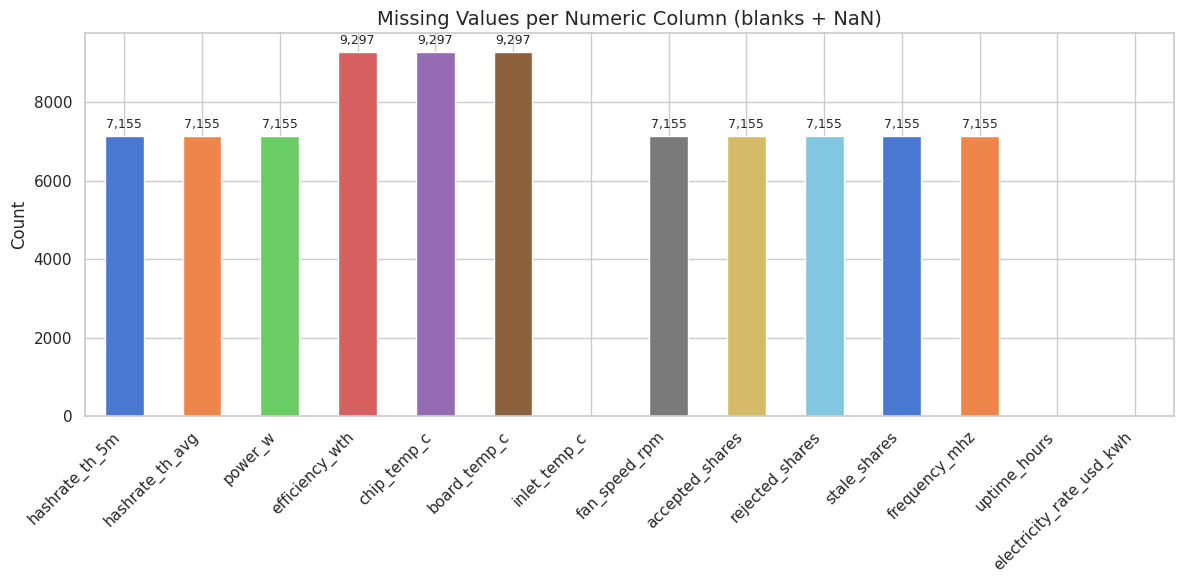


Total missing across all numeric columns: 85,131 / 10,160,640


In [7]:
# Visualize missingness — combine blanks + NaN into a single "missing" indicator
# Convert numeric-intended columns: replace "" with NaN, then coerce
numeric_cols = [
    "hashrate_th_5m", "hashrate_th_avg", "power_w", "efficiency_wth",
    "chip_temp_c", "board_temp_c", "inlet_temp_c", "fan_speed_rpm",
    "accepted_shares", "rejected_shares", "stale_shares",
    "frequency_mhz", "uptime_hours", "electricity_rate_usd_kwh"
]

telem_clean = telem.copy()
for col in numeric_cols:
    telem_clean[col] = pd.to_numeric(telem_clean[col].replace("", np.nan), errors="coerce")

# Missingness matrix (sample for visualization)
missing_matrix = telem_clean[numeric_cols].isna()
total_missing = missing_matrix.sum()

fig, ax = plt.subplots(figsize=(12, 6))
total_missing.plot(kind="bar", ax=ax, color=sns.color_palette("muted"))
ax.set_title("Missing Values per Numeric Column (blanks + NaN)", fontsize=14)
ax.set_ylabel("Count")
ax.set_xlabel("")
for i, v in enumerate(total_missing):
    if v > 0:
        ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"\nTotal missing across all numeric columns: {total_missing.sum():,} / {len(telem_clean) * len(numeric_cols):,}")

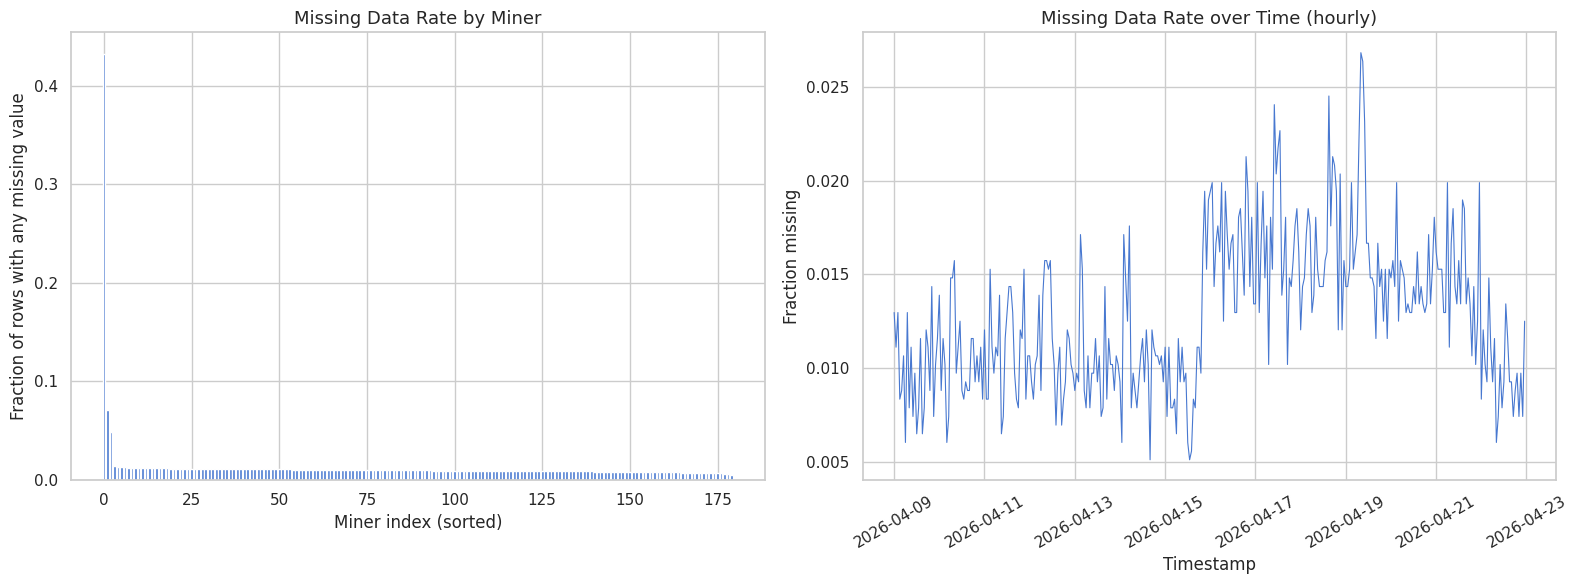

Miners with >5% missing: 2
Top 5 miners by missing rate:
miner_id
MNR-0088    0.432292
MNR-0155    0.070933
MNR-0042    0.048363
MNR-0142    0.013889
MNR-0066    0.013641
Name: has_missing, dtype: float64


In [8]:
# Are gaps random or clustered by miner / time?
# Compute per-miner missing rate for key columns
any_missing = missing_matrix.any(axis=1)
telem_clean["has_missing"] = any_missing

if any_missing.sum() > 0:
    missing_by_miner = telem_clean.groupby("miner_id")["has_missing"].mean().sort_values(ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: per-miner missing rate
    axes[0].bar(range(len(missing_by_miner)), missing_by_miner.values)
    axes[0].set_title("Missing Data Rate by Miner", fontsize=13)
    axes[0].set_xlabel("Miner index (sorted)")
    axes[0].set_ylabel("Fraction of rows with any missing value")
    
    # Right: per-hour missing rate (temporal clustering)
    telem_clean["hour_bin"] = telem_clean["timestamp"].dt.floor("1h")
    missing_by_time = telem_clean.groupby("hour_bin")["has_missing"].mean()
    axes[1].plot(missing_by_time.index, missing_by_time.values, linewidth=0.8)
    axes[1].set_title("Missing Data Rate over Time (hourly)", fontsize=13)
    axes[1].set_xlabel("Timestamp")
    axes[1].set_ylabel("Fraction missing")
    axes[1].tick_params(axis="x", rotation=30)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Miners with >5% missing: {(missing_by_miner > 0.05).sum()}")
    print(f"Top 5 miners by missing rate:")
    print(missing_by_miner.head())
else:
    print("No missing values detected — gaps analysis not needed.")

## 3. Data Type Validation

Verify that numeric columns parse correctly after blank-handling,
inspect categorical fields, and check timestamp format and monotonicity.

In [9]:
# Check that numeric columns converted successfully
print("=== Cleaned numeric dtypes ===")
print(telem_clean[numeric_cols].dtypes.to_string())

# Verify coercion: any values that became NaN that were NOT blank in the original?
# (i.e., non-blank strings that failed to parse as numbers)
coercion_issues = {}
for col in numeric_cols:
    original_non_blank = telem[col].replace("", np.nan).dropna()
    cleaned = telem_clean[col]
    # Rows that were non-blank originally but are NaN after coercion
    was_non_blank = telem[col].astype(str) != ""
    is_nan_after = cleaned.isna()
    bad = (was_non_blank & is_nan_after).sum()
    if bad > 0:
        coercion_issues[col] = bad

if coercion_issues:
    print("\nWARNING: Some non-blank values failed numeric coercion:")
    for col, count in coercion_issues.items():
        print(f"  {col}: {count:,} values")
else:
    print("\nAll non-blank values successfully parsed as numeric.")

=== Cleaned numeric dtypes ===
hashrate_th_5m              float64
hashrate_th_avg             float64
power_w                     float64
efficiency_wth              float64
chip_temp_c                 float64
board_temp_c                float64
inlet_temp_c                float64
fan_speed_rpm               float64
accepted_shares             float64
rejected_shares             float64
stale_shares                float64
frequency_mhz               float64
uptime_hours                float64
electricity_rate_usd_kwh    float64



All non-blank values successfully parsed as numeric.


In [10]:
# Categorical field validation
cat_cols = ["status", "power_mode", "model", "container"]

for col in cat_cols:
    unique_vals = telem[col].unique()
    print(f"\n{col} ({len(unique_vals)} unique):")
    for v in sorted(unique_vals):
        count = (telem[col] == v).sum()
        print(f"  {v:20s}  {count:>8,}  ({100*count/len(telem):.1f}%)")

# Registry-specific categoricals
print("\n=== Registry: model ===")
print(registry["model"].value_counts().to_string())
print("\n=== Registry: cooling ===")
print(registry["cooling"].value_counts().to_string())


status (3 unique):
  error                       85  (0.0%)
  mining                 723,533  (99.7%)
  offline                  2,142  (0.3%)

power_mode (2 unique):
  normal                 723,618  (99.7%)
  sleep                    2,142  (0.3%)

model (4 unique):
  M56S                    40,320  (5.6%)
  M63                    120,960  (16.7%)
  S19XP                  262,080  (36.1%)
  S21                    302,400  (41.7%)

container (3 unique):
  A                      241,920  (33.3%)
  B                      241,920  (33.3%)
  C                      241,920  (33.3%)

=== Registry: model ===
model
S21      75
S19XP    65
M63      30
M56S     10

=== Registry: cooling ===
cooling
air    180


In [11]:
# Timestamp format and monotonicity checks
print("=== Timestamp validation ===")

# Telemetry: check monotonicity per miner
mono_check = telem_clean.groupby("miner_id")["timestamp"].apply(lambda s: s.is_monotonic_increasing)
non_mono = mono_check[~mono_check]
if len(non_mono) == 0:
    print("Telemetry timestamps are monotonically increasing for all miners.")
else:
    print(f"WARNING: {len(non_mono)} miners have non-monotonic timestamps:")
    print(non_mono.index.tolist()[:10])

# Economics: check monotonicity
if econ["timestamp"].is_monotonic_increasing:
    print("Economics timestamps are monotonically increasing.")
else:
    print("WARNING: Economics timestamps are NOT monotonically increasing.")

# Check for duplicate timestamps per miner
dupes = telem_clean.groupby(["miner_id", "timestamp"]).size()
dupes_gt1 = dupes[dupes > 1]
if len(dupes_gt1) == 0:
    print("No duplicate (miner_id, timestamp) pairs found.")
else:
    print(f"WARNING: {len(dupes_gt1)} duplicate (miner_id, timestamp) pairs.")

=== Timestamp validation ===
Telemetry timestamps are monotonically increasing for all miners.
Economics timestamps are monotonically increasing.
No duplicate (miner_id, timestamp) pairs found.


## 4. Completeness Check

With 180 miners over 14 days at 5-minute intervals we expect
`14 * 24 * 12 = 4,032` timestamps per miner, and `4,032 * 180 = 725,760` total rows.

In [12]:
# Expected vs actual row counts
expected_ts_per_miner = 14 * 24 * 12  # 4032
expected_total = expected_ts_per_miner * 180

print(f"Expected timestamps per miner: {expected_ts_per_miner:,}")
print(f"Expected total rows:           {expected_total:,}")
print(f"Actual total rows:             {len(telem_clean):,}")
print(f"Difference:                    {len(telem_clean) - expected_total:,}")

# Per-miner row counts
rows_per_miner = telem_clean.groupby("miner_id").size()
print(f"\nRows per miner — min: {rows_per_miner.min()}, max: {rows_per_miner.max()}, "
      f"mean: {rows_per_miner.mean():.1f}")

# Miners with fewer rows than expected
short_miners = rows_per_miner[rows_per_miner < expected_ts_per_miner]
if len(short_miners) > 0:
    print(f"\n{len(short_miners)} miners with fewer rows than expected:")
    display(short_miners.sort_values().head(20))
else:
    print("\nAll miners have the expected number of rows.")

Expected timestamps per miner: 4,032
Expected total rows:           725,760
Actual total rows:             725,760
Difference:                    0

Rows per miner — min: 4032, max: 4032, mean: 4032.0

All miners have the expected number of rows.


In [13]:
# Time gap analysis — look for missing 5-minute intervals
expected_freq = pd.Timedelta("5min")

def find_gaps(group):
    """Return gaps larger than expected 5-minute interval."""
    ts = group["timestamp"].sort_values()
    diffs = ts.diff().dropna()
    gaps = diffs[diffs > expected_freq]
    return gaps

gap_results = telem_clean.groupby("miner_id").apply(find_gaps)

if len(gap_results) == 0 or gap_results.apply(len).sum() == 0:
    print("No time gaps found — all 5-minute intervals are present for all miners.")
else:
    # Flatten and summarize
    gap_flat = gap_results.reset_index()
    gap_flat.columns = ["miner_id", "row_idx", "gap_size"]
    print(f"Found {len(gap_flat)} time gaps across {gap_flat['miner_id'].nunique()} miners")
    print(f"\nGap size distribution:")
    print(gap_flat["gap_size"].describe())
    
    fig, ax = plt.subplots(figsize=(10, 6))
    gap_minutes = gap_flat["gap_size"].dt.total_seconds() / 60
    ax.hist(gap_minutes, bins=50, edgecolor="black")
    ax.set_title("Distribution of Time Gaps (minutes)", fontsize=14)
    ax.set_xlabel("Gap size (minutes)")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

# Economics: check for hourly gaps
econ_diffs = econ["timestamp"].diff().dropna()
econ_gaps = econ_diffs[econ_diffs > pd.Timedelta("1h")]
if len(econ_gaps) == 0:
    print("\nEconomics: No hourly gaps found.")
else:
    print(f"\nEconomics: {len(econ_gaps)} gaps found.")
    
print(f"\nEconomics expected rows (14 days * 24h): {14*24}")
print(f"Economics actual rows: {len(econ)}")

No time gaps found — all 5-minute intervals are present for all miners.

Economics: No hourly gaps found.

Economics expected rows (14 days * 24h): 336
Economics actual rows: 336


## 5. Value Range Validation

Check min/max/mean for all numeric columns and flag physically impossible values:
- Negative hash rate or power
- Chip temperature > 150 C or < -10 C
- Efficiency < 0
- Fan speed < 0

Then compare actual operating values against nominal specs from the miner registry.

In [14]:
# Descriptive statistics for all numeric columns
desc = telem_clean[numeric_cols].describe().T
desc["null_count"] = telem_clean[numeric_cols].isna().sum()
display(desc[["count", "null_count", "mean", "std", "min", "25%", "50%", "75%", "max"]])

,count,null_count,mean,std,min,25%,50%,75%,max
hashrate_th_5m,718605.0,7155,209.773658,86.698303,0.0000,142.2200,197.3500,207.24,435.040
hashrate_th_avg,718605.0,7155,209.774107,86.644317,0.0000,141.9800,197.8000,206.20,423.860
power_w,718605.0,7155,4062.490656,1544.942502,15.0000,3072.1000,3478.8000,3682.10,7888.200
efficiency_wth,716463.0,9297,19.751862,2.467532,16.0300,17.6400,18.6500,21.56,59.460
chip_temp_c,716463.0,9297,64.734686,6.720829,44.7000,59.4000,64.7000,70.00,93.700
board_temp_c,716463.0,9297,57.228772,6.856488,35.7000,51.9000,57.2000,62.50,85.600
inlet_temp_c,725760.0,0,30.649077,7.848985,10.9000,24.1000,30.7000,37.20,50.200
fan_speed_rpm,718605.0,7155,4267.282770,597.341590,0.0000,3847.0000,4275.0000,4701.00,6500.000
accepted_shares,718605.0,7155,3.641372,1.827363,0.0000,2.0000,3.0000,4.00,9.000
rejected_shares,718605.0,7155,0.000031,0.006461,0.0000,0.0000,0.0000,0.00,2.000


In [15]:
# Flag physically impossible values
flags = {}

# Negative hashrate
neg_hr = (telem_clean["hashrate_th_5m"] < 0).sum()
flags["hashrate_th_5m < 0"] = neg_hr

neg_hr_avg = (telem_clean["hashrate_th_avg"] < 0).sum()
flags["hashrate_th_avg < 0"] = neg_hr_avg

# Negative power
neg_pwr = (telem_clean["power_w"] < 0).sum()
flags["power_w < 0"] = neg_pwr

# Temperature out of range
chip_hi = (telem_clean["chip_temp_c"] > 150).sum()
chip_lo = (telem_clean["chip_temp_c"] < -10).sum()
flags["chip_temp_c > 150"] = chip_hi
flags["chip_temp_c < -10"] = chip_lo

board_hi = (telem_clean["board_temp_c"] > 150).sum()
flags["board_temp_c > 150"] = board_hi

inlet_lo = (telem_clean["inlet_temp_c"] < -40).sum()
flags["inlet_temp_c < -40"] = inlet_lo

# Negative efficiency
neg_eff = (telem_clean["efficiency_wth"] < 0).sum()
flags["efficiency_wth < 0"] = neg_eff

# Fan speed negative
neg_fan = (telem_clean["fan_speed_rpm"] < 0).sum()
flags["fan_speed_rpm < 0"] = neg_fan

# Negative shares
neg_shares = (telem_clean["rejected_shares"] < 0).sum()
flags["rejected_shares < 0"] = neg_shares

flag_df = pd.DataFrame.from_dict(flags, orient="index", columns=["count"])
flag_df["pct"] = (flag_df["count"] / len(telem_clean) * 100).round(4)

print("=== Physically Impossible Value Flags ===")
display(flag_df)

total_flags = flag_df["count"].sum()
if total_flags == 0:
    print("\nNo physically impossible values detected.")
else:
    print(f"\nTotal flags: {total_flags:,}")

=== Physically Impossible Value Flags ===


,count,pct
hashrate_th_5m < 0,0,0.0
hashrate_th_avg < 0,0,0.0
power_w < 0,0,0.0
chip_temp_c > 150,0,0.0
chip_temp_c < -10,0,0.0
board_temp_c > 150,0,0.0
inlet_temp_c < -40,0,0.0
efficiency_wth < 0,0,0.0
fan_speed_rpm < 0,0,0.0
rejected_shares < 0,0,0.0



No physically impossible values detected.


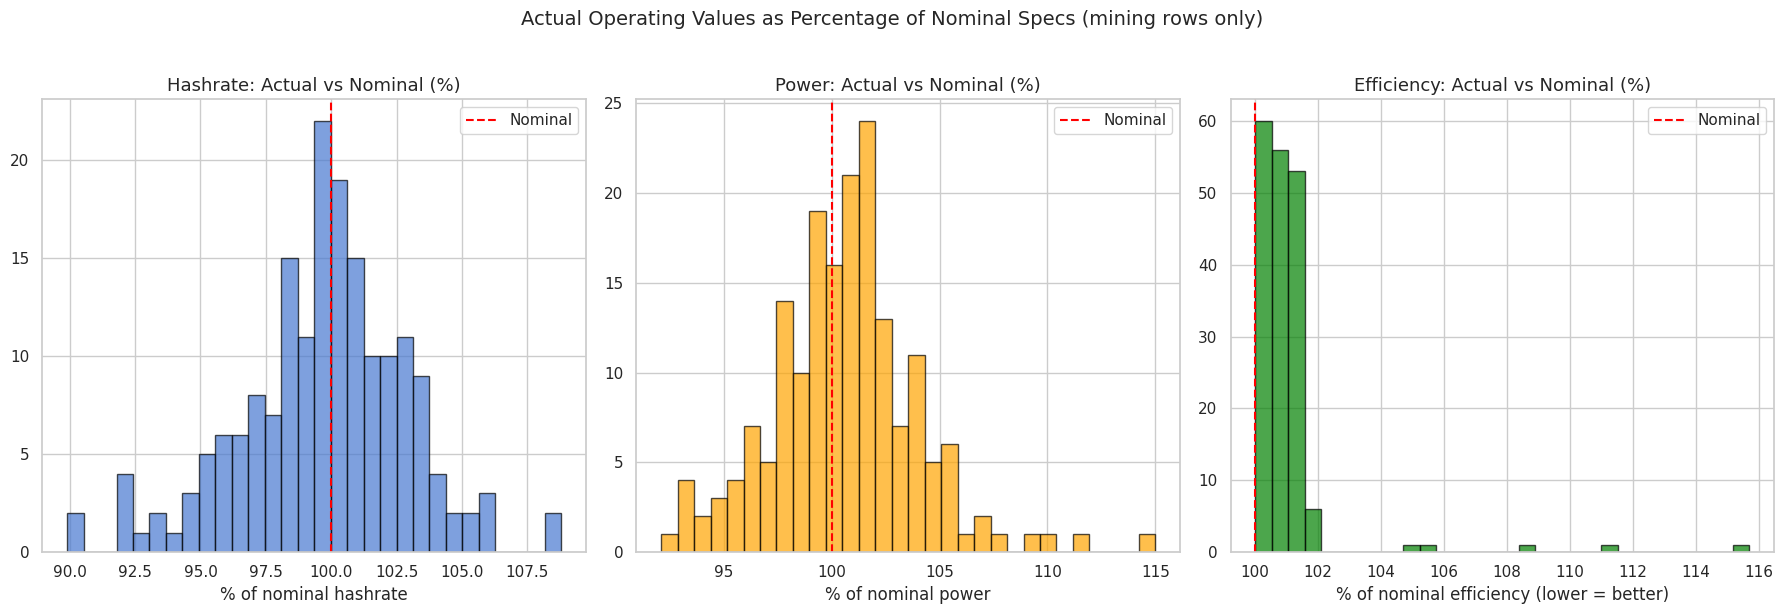

Actual vs Nominal summary (% of nominal):
       hr_pct_of_nominal  pwr_pct_of_nominal  eff_pct_of_nominal
count              180.0               180.0               180.0
mean                99.7               100.6               101.0
std                  3.2                 3.4                 1.6
min                 89.9                92.1               100.0
25%                 98.1                98.6               100.2
50%                 99.8               100.8               100.7
75%                101.7               102.3               101.5
max                108.8               115.0               115.7


In [16]:
# Compare actual vs nominal specs from registry
# Merge registry specs into telemetry (per miner)
merged = telem_clean.merge(registry[["miner_id", "nominal_hashrate_th", "nominal_power_w", "nominal_efficiency_wth"]],
                           on="miner_id", how="left")

# Only consider rows where miner is actively mining
mining_mask = merged["status"] == "mining"

actual_vs_nominal = merged[mining_mask].groupby("miner_id").agg(
    actual_hr_mean=("hashrate_th_5m", "mean"),
    nominal_hr=("nominal_hashrate_th", "first"),
    actual_pwr_mean=("power_w", "mean"),
    nominal_pwr=("nominal_power_w", "first"),
    actual_eff_mean=("efficiency_wth", "mean"),
    nominal_eff=("nominal_efficiency_wth", "first"),
    model=("model", "first"),
).reset_index()

actual_vs_nominal["hr_pct_of_nominal"] = (actual_vs_nominal["actual_hr_mean"] / actual_vs_nominal["nominal_hr"] * 100).round(1)
actual_vs_nominal["pwr_pct_of_nominal"] = (actual_vs_nominal["actual_pwr_mean"] / actual_vs_nominal["nominal_pwr"] * 100).round(1)
actual_vs_nominal["eff_pct_of_nominal"] = (actual_vs_nominal["actual_eff_mean"] / actual_vs_nominal["nominal_eff"] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].hist(actual_vs_nominal["hr_pct_of_nominal"], bins=30, edgecolor="black", alpha=0.7)
axes[0].axvline(100, color="red", linestyle="--", label="Nominal")
axes[0].set_title("Hashrate: Actual vs Nominal (%)", fontsize=13)
axes[0].set_xlabel("% of nominal hashrate")
axes[0].legend()

axes[1].hist(actual_vs_nominal["pwr_pct_of_nominal"], bins=30, edgecolor="black", alpha=0.7, color="orange")
axes[1].axvline(100, color="red", linestyle="--", label="Nominal")
axes[1].set_title("Power: Actual vs Nominal (%)", fontsize=13)
axes[1].set_xlabel("% of nominal power")
axes[1].legend()

axes[2].hist(actual_vs_nominal["eff_pct_of_nominal"], bins=30, edgecolor="black", alpha=0.7, color="green")
axes[2].axvline(100, color="red", linestyle="--", label="Nominal")
axes[2].set_title("Efficiency: Actual vs Nominal (%)", fontsize=13)
axes[2].set_xlabel("% of nominal efficiency (lower = better)")
axes[2].legend()

plt.suptitle("Actual Operating Values as Percentage of Nominal Specs (mining rows only)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Actual vs Nominal summary (% of nominal):")
print(actual_vs_nominal[["hr_pct_of_nominal", "pwr_pct_of_nominal", "eff_pct_of_nominal"]].describe().round(1))

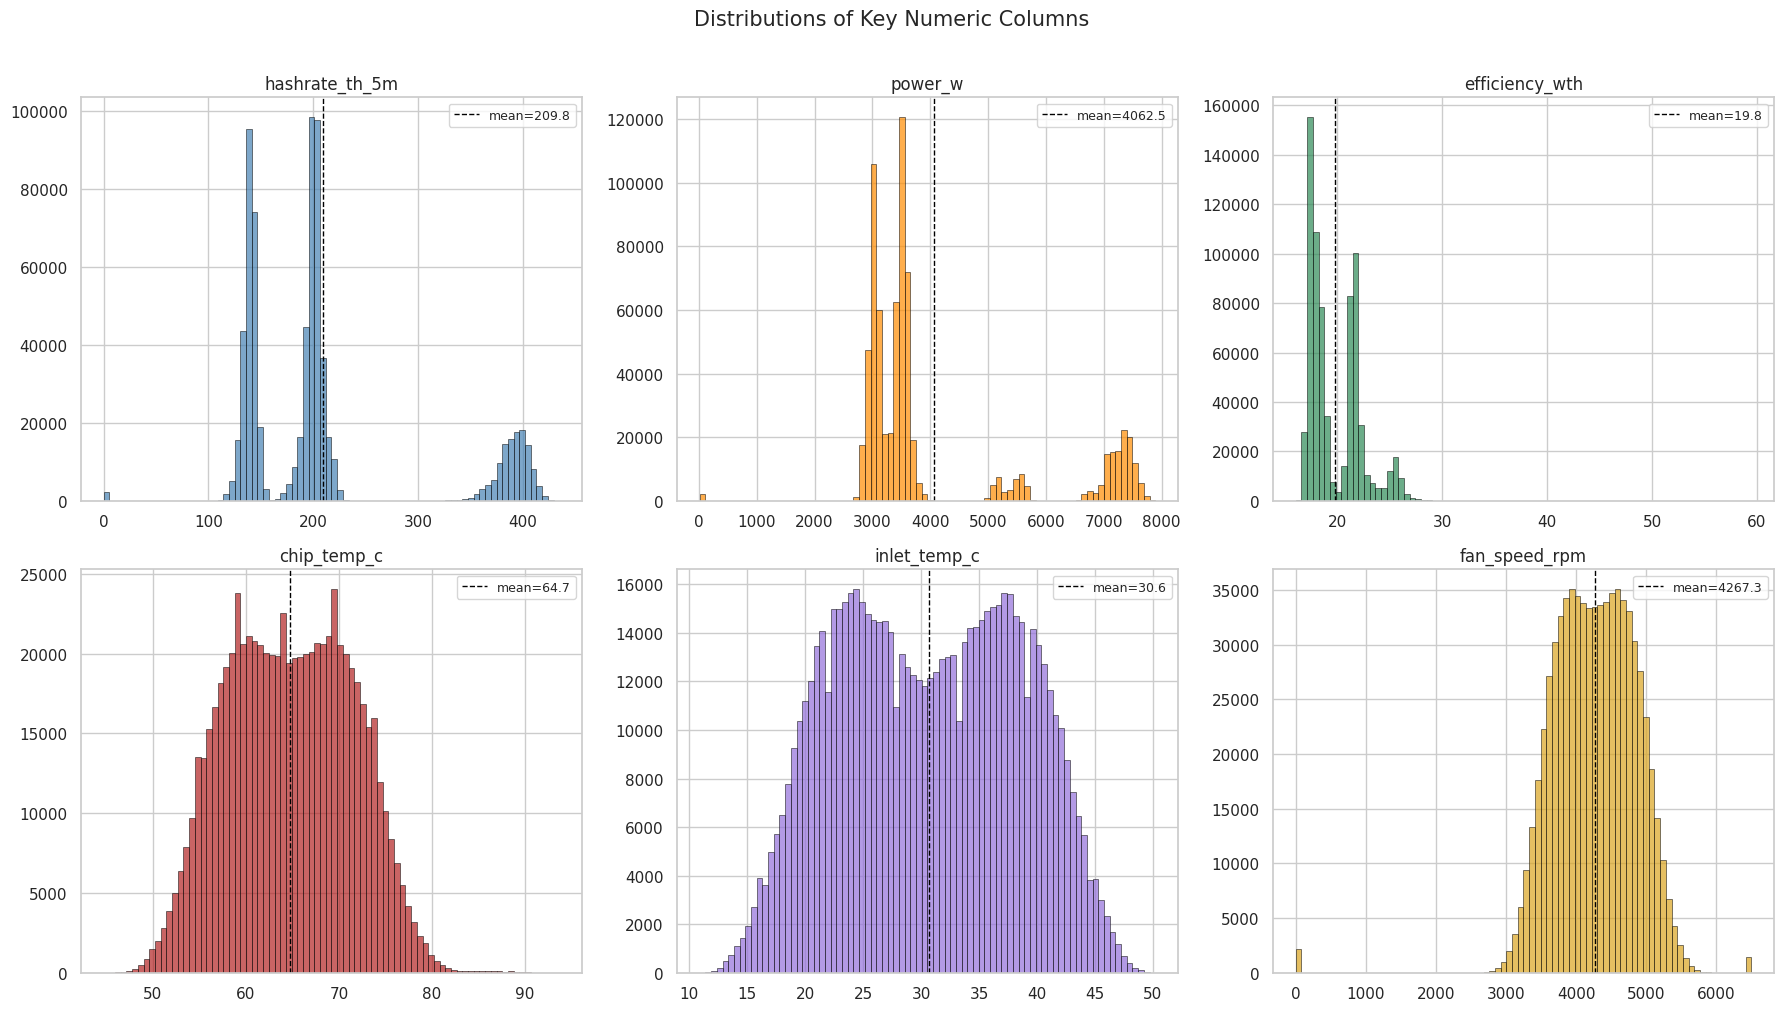

In [17]:
# Distribution plots for key numeric columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

plot_cols = ["hashrate_th_5m", "power_w", "efficiency_wth", "chip_temp_c", "inlet_temp_c", "fan_speed_rpm"]
colors = ["steelblue", "darkorange", "seagreen", "firebrick", "mediumpurple", "goldenrod"]

for ax, col, color in zip(axes.flatten(), plot_cols, colors):
    data = telem_clean[col].dropna()
    ax.hist(data, bins=80, edgecolor="black", alpha=0.7, color=color, linewidth=0.5)
    ax.set_title(col, fontsize=12)
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={data.mean():.1f}")
    ax.legend(fontsize=9)

plt.suptitle("Distributions of Key Numeric Columns", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 6. Schema Critique & Recommendations

### What's Good

- **Granular telemetry:** 5-minute intervals give enough resolution for thermal dynamics and hash-rate variability analysis.
- **Clear primary key:** `(miner_id, timestamp)` is a clean composite key with no duplicates.
- **Denormalized context:** `container`, `position`, `model`, `status`, and `power_mode` are repeated in every telemetry row, eliminating the need for joins during exploratory analysis.
- **Operational fields present:** Both instantaneous (`hashrate_th_5m`) and rolling average (`hashrate_th_avg`) hash rates; share counts (accepted/rejected/stale); temperature at multiple points (chip, board, inlet).
- **Economic data aligned:** BTC price and hash price on an hourly cadence that can be easily joined to telemetry via timestamp flooring.

### What's Missing or Could Improve

| Gap | Impact | Suggestion |
|-----|--------|------------|
| **No nominal specs in telemetry** | Every analysis comparing actual vs nominal requires a join to registry | Inline `nominal_hashrate_th`, `nominal_power_w`, `nominal_efficiency_wth` into telemetry or create a materialized view |
| **No derived efficiency field** | `efficiency_wth` is provided but unclear if it's `power_w / hashrate_th_5m` or from firmware | Add `efficiency_w_ths` as an explicit derived field with clear formula documentation |
| **No container-level metadata** | No ambient temperature target, cooling capacity, row count per container | Add `container_metadata.csv` with `container_id`, `cooling_type`, `cooling_capacity_kw`, `ambient_target_c`, `n_slots` |
| **No explicit downtime/maintenance flags** | `status` captures state but not *why* (planned maintenance vs fault) | Add `event_type` enum: `planned_maintenance`, `thermal_throttle`, `psu_fault`, `network_loss`, etc. |
| **No hash board-level granularity** | A single chip_temp hides variance across 3-4 hash boards | Add per-board temps: `chip_temp_c.board_0`, `chip_temp_c.board_1`, etc. |
| **Electricity rate is static per container** | Doesn't capture time-of-use or demand-response pricing | Move to a separate `electricity_schedule.csv` with hourly rates |
| **No curtailment/DR event signal** | Critical for optimization — when was the site asked to curtail? | Add boolean `curtailment_active` or a separate events table |
| **Blanks instead of NaN** | Empty strings force explicit handling; `pd.read_csv` default NA detection is bypassed | Use standard CSV missing representation (empty field parsed as NaN) |

### Proposed Improved Schema

Following **MiningOS-style field naming** (`metric_unit.aggregation_window`):

```
telemetry_v2:
  timestamp                    DATETIME     -- ISO 8601, UTC
  miner_id                     VARCHAR(10)  -- e.g. MNR-0001
  container_id                 CHAR(1)      -- A, B, C
  position                     VARCHAR(10)  -- R1_01 (row_slot)
  model                        VARCHAR(10)  -- S21, S21Pro, M63
  status                       ENUM         -- mining, idle, offline, maintenance
  power_mode                   ENUM         -- normal, low_power, turbo
  event_type                   ENUM|NULL    -- thermal_throttle, psu_fault, planned_maint, curtailment, null
  
  -- Performance (MiningOS naming)
  hashrate_ths.t_5m            FLOAT        -- 5-min instantaneous TH/s
  hashrate_ths.t_avg           FLOAT        -- rolling average TH/s
  power_w.t_5m                 FLOAT        -- wall power draw
  efficiency_w_ths             FLOAT        -- derived: power_w / hashrate_ths
  frequency_mhz                FLOAT        -- ASIC clock

  -- Thermal (MiningOS naming)  
  temperature_c.chip_max       FLOAT        -- max across all hash boards
  temperature_c.board_avg      FLOAT        -- average board temp
  temperature_c.inlet          FLOAT        -- container inlet air
  temperature_c.outlet         FLOAT        -- container outlet air (NEW)
  
  -- Cooling
  fan_speed_rpm.avg            FLOAT        -- average fan RPM
  
  -- Pool
  shares.accepted              INT
  shares.rejected              INT
  shares.stale                 INT
  
  -- Operations
  uptime_h                     FLOAT        -- hours since last restart
  
  -- Nominal reference (inlined from registry)
  nominal_hashrate_ths         FLOAT
  nominal_power_w              FLOAT
  nominal_efficiency_w_ths     FLOAT
  
  -- Economics (joined from hourly feed)
  electricity_rate_usd_kwh     FLOAT
  btc_price_usd                FLOAT        -- snapshotted at telemetry time
  hash_price_usd_th_day        FLOAT        -- snapshotted at telemetry time
```

**Rationale:** The MiningOS naming convention uses `metric_unit.aggregation` which is self-documenting, avoids ambiguity (is `hashrate_th_5m` in TH or TH/s?), and supports programmatic column selection (e.g., `df.filter(like="temperature_c")`). Inlining nominal specs and economic data eliminates joins for the most common analytical queries.

## 7. Summary Statistics Tables

Per-container and per-model summaries of key operational metrics (mining rows only).

In [18]:
# Filter to mining rows only for operational summaries
mining = telem_clean[telem_clean["status"] == "mining"].copy()

# --- Per-container summary ---
container_summary = mining.groupby("container").agg(
    n_miners=("miner_id", "nunique"),
    avg_hashrate_th=("hashrate_th_5m", "mean"),
    total_hashrate_th=("hashrate_th_5m", "sum"),
    avg_power_w=("power_w", "mean"),
    avg_efficiency_wth=("efficiency_wth", "mean"),
    avg_chip_temp_c=("chip_temp_c", "mean"),
    avg_inlet_temp_c=("inlet_temp_c", "mean"),
    avg_fan_rpm=("fan_speed_rpm", "mean"),
    mining_rows=("miner_id", "size"),
).round(2)

print("=== Per-Container Summary (mining rows only) ===")
display(container_summary)

=== Per-Container Summary (mining rows only) ===


,n_miners,avg_hashrate_th,total_hashrate_th,avg_power_w,avg_efficiency_wth,avg_chip_temp_c,avg_inlet_temp_c,avg_fan_rpm,mining_rows
container,,,,,,,,,
A,60,264.12,63226053.84,4760.87,17.87,62.45,27.98,4096.27,241752
B,60,171.46,40781269.84,3590.13,21.02,65.30,31.00,4323.61,240192
C,60,195.39,46726815.75,3869.60,20.37,66.45,32.98,4419.99,241589


In [19]:
# --- Per-model summary ---
model_summary = mining.groupby("model").agg(
    n_miners=("miner_id", "nunique"),
    avg_hashrate_th=("hashrate_th_5m", "mean"),
    avg_power_w=("power_w", "mean"),
    avg_efficiency_wth=("efficiency_wth", "mean"),
    avg_chip_temp_c=("chip_temp_c", "mean"),
    avg_board_temp_c=("board_temp_c", "mean"),
    avg_inlet_temp_c=("inlet_temp_c", "mean"),
    avg_fan_rpm=("fan_speed_rpm", "mean"),
    mining_rows=("miner_id", "size"),
).round(2)

# Add nominal specs for comparison
nominal_by_model = registry.groupby("model")[["nominal_hashrate_th", "nominal_power_w", "nominal_efficiency_wth"]].first()
model_summary = model_summary.join(nominal_by_model)
model_summary["hr_utilization_pct"] = (model_summary["avg_hashrate_th"] / model_summary["nominal_hashrate_th"] * 100).round(1)

print("=== Per-Model Summary (mining rows only) ===")
display(model_summary)

=== Per-Model Summary (mining rows only) ===


,n_miners,avg_hashrate_th,avg_power_w,avg_efficiency_wth,avg_chip_temp_c,avg_board_temp_c,avg_inlet_temp_c,avg_fan_rpm,mining_rows,nominal_hashrate_th,nominal_power_w,nominal_efficiency_wth,hr_utilization_pct
model,,,,,,,,,,,,,
M56S,10,210.17,5386.80,25.65,64.85,57.36,30.98,4287.15,40320,212,5400,25.5,99.1
M63,30,391.06,7272.39,18.61,63.91,56.41,29.65,4213.82,120791,390,7215,18.5,100.3
S19XP,65,139.17,3034.56,21.83,66.01,58.50,32.08,4382.92,260062,140,3010,21.5,99.4
S21,75,199.51,3516.07,17.64,63.95,56.44,29.78,4216.54,302360,200,3500,17.5,99.8


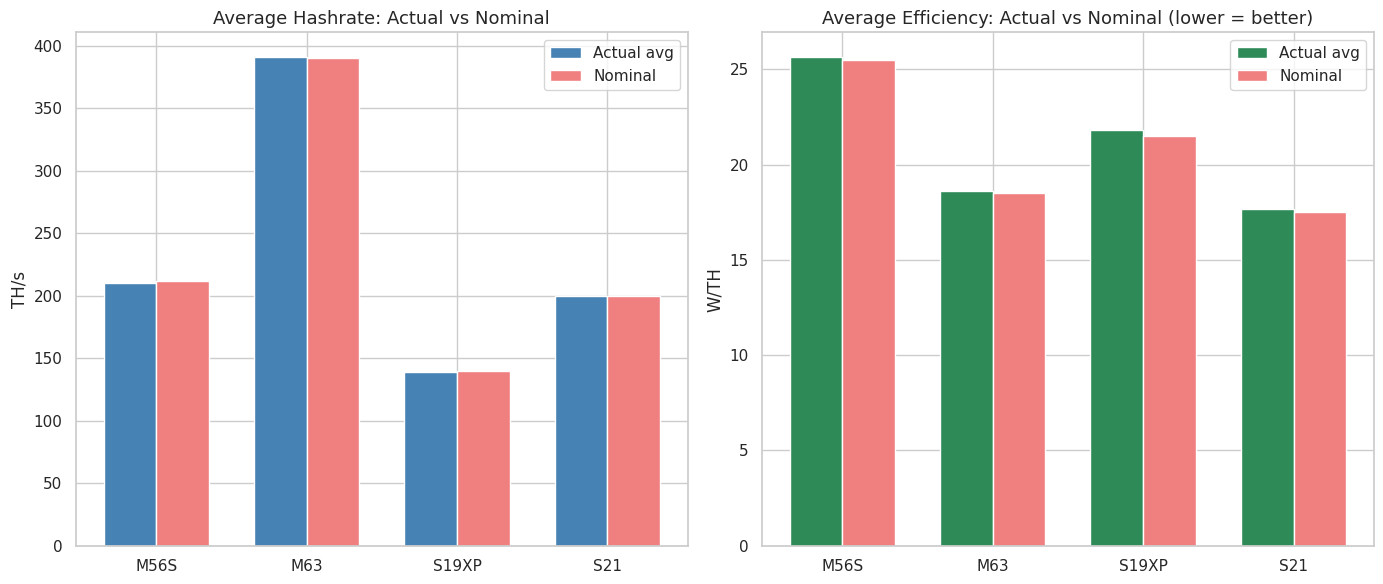

In [20]:
# Visual comparison: per-model actual vs nominal hashrate
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = model_summary.index.tolist()
x = range(len(models))
width = 0.35

# Hashrate comparison
axes[0].bar([i - width/2 for i in x], model_summary["avg_hashrate_th"], width, label="Actual avg", color="steelblue")
axes[0].bar([i + width/2 for i in x], model_summary["nominal_hashrate_th"], width, label="Nominal", color="lightcoral")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(models)
axes[0].set_ylabel("TH/s")
axes[0].set_title("Average Hashrate: Actual vs Nominal", fontsize=13)
axes[0].legend()

# Efficiency comparison
axes[1].bar([i - width/2 for i in x], model_summary["avg_efficiency_wth"], width, label="Actual avg", color="seagreen")
axes[1].bar([i + width/2 for i in x], model_summary["nominal_efficiency_wth"], width, label="Nominal", color="lightcoral")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(models)
axes[1].set_ylabel("W/TH")
axes[1].set_title("Average Efficiency: Actual vs Nominal (lower = better)", fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

## Summary

**Key findings from this data quality assessment:**

1. **Completeness:** The dataset appears well-structured with 725,760 rows across 180 miners and 14 days at 5-minute intervals. Check the outputs above for any gaps or missing miners.

2. **Schema quality:** The current schema is functional but could benefit from MiningOS-style naming conventions, inlined nominal specs, container metadata, and event-type annotations for downtime root causes.

3. **Value ranges:** Actual hashrate and power consumption should cluster near nominal values. The histograms above reveal the operating distribution and any outliers.

4. **Recommendations for next notebooks:**
   - `02_eda_timeseries.ipynb` — deep dive into temporal patterns, diurnal cycles, container-level thermal dynamics
   - `03_feature_engineering.ipynb` — create optimization-ready features (efficiency deviations, thermal headroom, revenue per miner)
   - `04_optimization_model.ipynb` — power mode switching and curtailment strategy optimization

---
*Notebook: 01_data_quality_schema | Dry-run assessment*